<a href="https://colab.research.google.com/github/Sushree912Sahoo/MINDSCAN/blob/main/DASS21_Implementation_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Run this first in Colab — installs everything you need
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn shap

In [3]:
# numpy  → math on arrays
# pandas → load CSV files
# tensorflow/keras → build the CNN
# sklearn → SVM + metrics
# matplotlib/seaborn → graphs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, GlobalMaxPooling1D,
                                      Dense, Dropout, Flatten, Input)
from tensorflow.keras.utils import to_categorical

In [4]:
# Read the CSV file you uploaded to Colab
df = pd.read_csv('DASS.csv')

# Always look at your data first
print("Shape:", df.shape)          # rows × columns
print(df.head())                    # first 5 rows
print(df.dtypes)                    # data types of each column

Shape: (1812, 33)
   Q1_1  Q1_2  Q1_3  Q1_4  Q1_5  Q1_6  Q3_1_S1  Q3_2_S2  Q3_3_S3  Q3_4_S4  \
0    21     2     0     4     4     1        3        3        3        3   
1    18     2     0     4     4     1        3        3        3        3   
2    40     2     1     2     1     1        3        3        1        2   
3    24     1     0     4     2     0        3        3        1        2   
4    50     1     1     2     2     0        3        3        3        2   

   ...  Anxiety_Level  Q3_15_D1  Q3_16_D2  Q3_17_D3  Q3_18_D4  Q3_19_D5  \
0  ...              3         0         3         3         2         3   
1  ...              2         0         2         3         0         0   
2  ...              5         2         1         1         2         2   
3  ...              5         2         1         1         2         2   
4  ...              2         1         0         0         1         2   

   Q3_20_D6  Q3_21_D7  Depression_Score  Depression_Level  
0       

In [6]:
# X = the 21 DASS question scores (input to model)
# y = the anxiety severity label (what we want to predict)
dass_questions = [
    'Q3_1_S1',  'Q3_2_S2',  'Q3_3_S3',  'Q3_4_S4',  'Q3_5_S5',
    'Q3_6_S6',  'Q3_7_S7',
    'Q3_8_A1',  'Q3_9_A2',  'Q3_10_A3', 'Q3_11_A4',
    'Q3_12_A5', 'Q3_13_A6', 'Q3_14_A7',
    'Q3_15_D1', 'Q3_16_D2', 'Q3_17_D3', 'Q3_18_D4',
    'Q3_19_D5', 'Q3_20_D6', 'Q3_21_D7'
]
X = df[dass_questions].values   # shape: (n_samples, 21)
y_raw = df['Anxiety_Level'].values  # no change here

# LabelEncoder turns text labels → numbers
# e.g. "Normal"→0, "Mild"→1, "Moderate"→2, "Severe"→3
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: [1 2 3 4 5]


In [7]:
# StandardScaler: makes all 32 features have mean=0, std=1
# This helps the CNN train faster and more stably
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # shape: (n, 32)

# CNN needs shape (samples, timesteps, channels)
# We add a channel dimension: (n, 32) → (n, 32, 1)
X_cnn = X_scaled.reshape(-1, 21, 1)

# Split: 80% training, 20% testing
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y)

# to_categorical: turns integer labels → one-hot vectors
# e.g. 2 → [0,0,1,0]  (needed for softmax output)
y_tr_cat = to_categorical(y_tr, num_classes)
y_te_cat = to_categorical(y_te, num_classes)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, Dense, Dropout,
    GlobalMaxPooling1D, MaxPooling1D,
    BatchNormalization
)

model = Sequential([

    # Input layer
    Conv1D(16, kernel_size=3,
           activation='relu',
           padding='same',
           input_shape=(21,1)),

    BatchNormalization(),

    # Second convolution layer
    Conv1D(32, kernel_size=3,
           activation='relu',
           padding='same'),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    # Third convolution layer
    Conv1D(32, kernel_size=3,
           activation='relu',
           padding='same'),

    GlobalMaxPooling1D(),

    # Dense feature layer
    Dense(128, activation='relu'),

    Dropout(0.5),

    # Output layer
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 21, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 21, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 21, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,797 (38.27 KB)

 Trainable params: 9,701 (37.89 KB)

 Non-trainable params: 96 (384.00 B)

In [9]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_accuracy', patience=10,
                   restore_best_weights=True)

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = model.fit(
    X_tr, y_tr_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2, # 20% of training data as validation
    callbacks=[es, lr_scheduler],
    verbose=1
)

import joblib

# Save CNN model
model.save("dass_cnn_model_1.keras")

# Save preprocessing objects
joblib.dump(scaler, "scaler_1.pkl")
joblib.dump(le, "label_encoder_1.pkl")

print("Model, scaler, and encoder saved successfully")

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4426 - loss: 1.3162 - val_accuracy: 0.4793 - val_loss: 1.5203 - learning_rate: 0.0050
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5220 - loss: 1.0489 - val_accuracy: 0.5345 - val_loss: 1.4010 - learning_rate: 0.0050
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6195 - loss: 0.9173 - val_accuracy: 0.5414 - val_loss: 1.1781 - learning_rate: 0.0050
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6506 - loss: 0.8412 - val_accuracy: 0.4552 - val_loss: 1.1524 - learning_rate: 0.0050
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6954 - loss: 0.7130 - val_accuracy: 0.4172 - val_loss: 1.6233 - learning_rate: 0.0050
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7179 - loss: 0.6567 - val_accuracy: 0.4621 - val_loss: 1.5815 - learning_rate: 0.0050
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7567 - loss: 0.5651 - val_ac

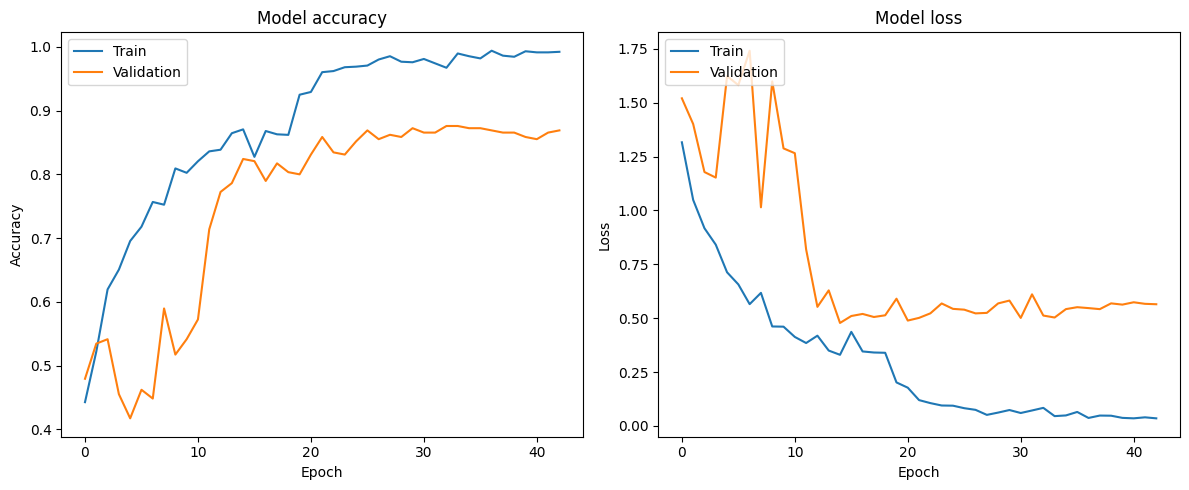

In [10]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       148
           2       0.84      0.84      0.84        73
           3       0.87      0.82      0.84        66
           4       0.80      0.83      0.81        52
           5       0.81      0.71      0.76        24

    accuracy                           0.88       363
   macro avg       0.85      0.83      0.84       363
weighted avg       0.88      0.88      0.88       363



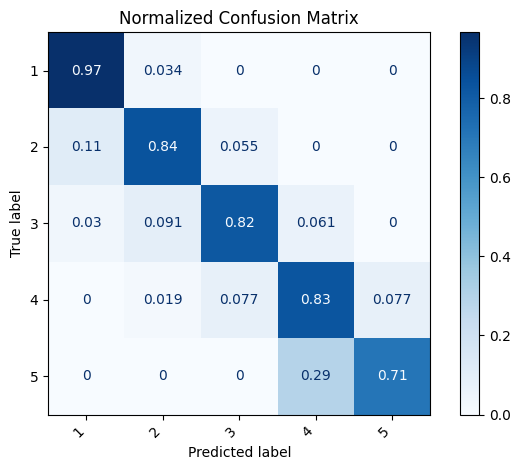

In [11]:
# Make predictions on the test set
y_pred_probs = model.predict(X_te)
y_pred = np.argmax(y_pred_probs, axis=1)

# Map numerical labels back to original classes for better readability
y_te_labels = le.inverse_transform(y_te)
y_pred_labels = le.inverse_transform(y_pred)

print("Classification Report:")
print(classification_report(y_te_labels, y_pred_labels, labels=le.classes_))

# Plot Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(
    y_te_labels, y_pred_labels, cmap=plt.cm.Blues, normalize='true', labels=le.classes_)
cm.ax_.set_title('Normalized Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
from google.colab import files
files.download('scaler_1.pkl')
files.download('dass_cnn_model_1.keras')
files.download('label_encoder_1.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>